# 04 — Final held-out evaluation

This notebook applies the validation-frozen analysis plan once to the held-out test cohort. Model
checkpoints, ensemble membership, decision thresholds, patient aggregation, and the eight
preregistered comparisons are inherited unchanged from validation; no test result is used for
selection or tuning. `RUN_TEST_INFERENCE` is the explicit inference-and-write gate, and all outputs are written to
the canonical run and final-evaluation namespaces for audit.

In [1]:
from pathlib import Path
import gc
import sys

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'configs').is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks/utility'))

import torch

from notebooks.utility.classifier_experiment import (
    configure_environment,
    experiment_configuration,
    load_existing_outputs,
    run_test,
)
from notebooks.utility.classifier_dataset_builder import test_rows
from notebooks.utility.classifier_analysis import (
    build_all_validation_ensembles,
    compare_validation,
    ensemble_metric_table,
    plot_ensemble_curves,
    plot_ensemble_overview,
)
from notebooks.utility.classifier_protocol import ARCHITECTURES, CONDITIONS, SEEDS

# Make one GPU visible, using the first job's policy.
base_configuration = experiment_configuration(ROOT, ARCHITECTURES[0], CONDITIONS[0], SEEDS[0])
base_configuration['root'] = str(ROOT)
_environment = configure_environment(base_configuration)
{
    key: _environment[key]
    for key in (
        'selection_policy', 'automatic_selection', 'observed_name',
        'observed_total_memory', 'local_index', 'physical_identity_verified',
    )
}

{'requested_selector': 'auto',
 'selection_policy': 'maximum_total_memory_then_lowest_physical_index',
 'automatic_selection': True,
 'resolved_physical_index': 1,
 'resolved_uuid': '<runtime-resolved>',
 'observed_name': 'NVIDIA GeForce RTX 5060 Ti',
 'observed_total_memory': 16616521728,
 'local_index': 0,
 'CUDA_VISIBLE_DEVICES': '<runtime-resolved>',
 'physical_identity_verified': True,
 'frameworks_already_initialized': [],
 'architecture': 'maxvit512',
 'seed': 17}

## 1. Load and audit the held-out test manifest

The cell resolves the canonical test metadata and reports image, patient, and class counts before any
model is loaded. Test rows are checked by the same path and identity rules used elsewhere, but remain
separate from training and validation artifacts. This inventory establishes the fixed evaluation
population and makes unexpected manifest changes visible.

In [2]:
test_data = test_rows(ROOT)
{
    'test_images': len(test_data),
    'test_patients': len({row['patient_id'] for row in test_data}),
    'positive_images': sum(1 for row in test_data if row['label'] == 1),
}

{'test_images': 438, 'test_patients': 438, 'positive_images': 73}

## 2. Run the gated one-time inference over all 24 checkpoints

When `RUN_TEST_INFERENCE=True`, each validation-selected `checkpoint_best` is applied to the held-out
rows and produces `test_predictions.csv` plus `test_metrics.json` beside its run artifacts. The code
does not search for a better checkpoint or threshold on test data, and compatible existing
predictions can be reused. Setting the gate to `False` prevents adapter construction and all test
inference, providing an explicit review mode.

In [3]:
RUN_TEST_INFERENCE = True

if RUN_TEST_INFERENCE:
    for architecture in ARCHITECTURES:
        for condition in CONDITIONS:
            for seed in SEEDS:
                configuration = experiment_configuration(ROOT, architecture, condition, seed)
                configuration['root'] = str(ROOT)
                checkpoint = load_existing_outputs(ROOT, configuration)['checkpoint']
                if checkpoint is None:
                    raise RuntimeError(
                        f'No trained checkpoint for {architecture}/{condition}/seed_{seed}.'
                    )
                result = run_test(ROOT, configuration, checkpoint, test_data)
                print(architecture, condition, seed, 'test PR-AUC', round(result['metrics']['pr_auc'], 4))
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
else:
    print('Test inference disabled: set RUN_TEST_INFERENCE = True to write test predictions.')

maxvit512 real_only 17 test PR-AUC 0.3089


maxvit512 real_only 42 test PR-AUC 0.3495


maxvit512 real_only 73 test PR-AUC 0.4085


maxvit512 real_augmented 17 test PR-AUC 0.4141


maxvit512 real_augmented 42 test PR-AUC 0.3682


...

mammofm real_plus_best_finetuned_positive 42 test PR-AUC 0.2999


mammofm real_plus_best_finetuned_positive 73 test PR-AUC 0.323


mammofm real_plus_best_fromscratch_positive 17 test PR-AUC 0.3057


mammofm real_plus_best_fromscratch_positive 42 test PR-AUC 0.313


mammofm real_plus_best_fromscratch_positive 73 test PR-AUC 0.3128


## 3. Reconstruct the eight frozen three-seed test ensembles

The same architecture–condition seed membership used on validation is applied to the aligned test
predictions. Probabilities are averaged across the three seeds at image level and then within patient,
with strict key, label, manifest, duplicate, and finiteness checks. Ensemble composition cannot be
changed in response to test performance.

In [4]:
test_ensembles = build_all_validation_ensembles(ROOT, split='test')
len(test_ensembles)

8

## 4. Estimate patient-level held-out performance

The final table reports the registered patient-level discrimination, Brier, and calibration metrics
with patient-resampled confidence intervals. These are the primary held-out estimates for the eight
frozen ensembles. Their uncertainty pertains to this cohort and should not be extrapolated to other
institutions or acquisition protocols without external validation.

In [5]:
test_comparison = compare_validation(ROOT, test_ensembles, split='test')
ensemble_metric_table(test_ensembles)

,architecture,condition,pr_auc,pr_auc_ci_low,pr_auc_ci_high,roc_auc,brier,ece,delta_pr_auc_vs_real_only,seed_pr_auc_mean,seed_pr_auc_std
0,maxvit512,real_only,0.412801,0.320225,0.522622,0.721786,0.127224,0.066192,0.000000,0.355623,0.050098
1,maxvit512,real_augmented,0.449671,0.346223,0.558649,0.745356,0.124448,0.069563,0.036871,0.398002,0.025850
2,maxvit512,real_plus_best_finetuned_positive,0.468164,0.361335,0.575920,0.740852,0.131689,0.111572,0.055363,0.424422,0.020359
3,maxvit512,real_plus_best_fromscratch_positive,0.522987,0.423427,0.622085,0.766786,0.120423,0.085096,0.110186,0.443720,0.050629
4,mammofm,real_only,0.324051,0.245057,0.413957,0.678889,0.178665,0.219196,0.000000,0.328419,0.046777
5,mammofm,real_augmented,0.312883,0.235355,0.408432,0.662526,0.224315,0.304108,-0.011168,0.304350,0.009698
6,mammofm,real_plus_best_finetuned_positive,0.323162,0.237972,0.422600,0.666204,0.165920,0.184925,-0.000889,0.317102,0.015126
7,mammofm,real_plus_best_fromscratch_positive,0.316120,0.236986,0.407511,0.666279,0.175591,0.202713,-0.007931,0.310508,0.004171


## 5. Apply the preregistered Holm family of eight comparisons

The exact comparison family defined on validation is evaluated on paired test-patient predictions:
three augmentation-versus-real-only contrasts and one fine-tuned-versus-from-scratch contrast within
each architecture. Holm adjustment is applied jointly to the eight p-values. No hypothesis is added,
removed, or reordered after observing held-out outcomes.

In [6]:
test_comparison['comparisons'], test_comparison['holm_correction']

([{'comparison_id': 'maxvit512:real_only_vs_real_augmented',
   'architecture': 'maxvit512',
   'condition_a': 'real_only',
   'condition_b': 'real_augmented',
   'metric': 'pr_auc',
   'n_bootstrap': 2000,
   'n_skipped_degenerate': 0,
   'seed': 20260714,
   'mean_a': 0.41677343971355046,
   'mean_b': 0.45181848660196816,
   'mean_diff_b_minus_a': 0.03504504688841763,
   'ci_95_low': -0.04571092600701869,
   'ci_95_high': 0.11212990137608751,
   'p_value_two_sided': 0.382},
  {'comparison_id': 'maxvit512:real_only_vs_real_plus_best_finetuned_positive',
   'architecture': 'maxvit512',
   'condition_a': 'real_only',
   'condition_b': 'real_plus_best_finetuned_positive',
   'metric': 'pr_auc',
   'n_bootstrap': 2000,
   'n_skipped_degenerate': 0,
   'seed': 20260714,
   'mean_a': 0.41677343971355046,
   'mean_b': 0.46990542607339764,
   'mean_diff_b_minus_a': 0.053131986359847144,
   'ci_95_low': -0.02319995083086098,
   'ci_95_high': 0.12763040055642244,
   'p_value_two_sided': 0.175},

## 6. Render final descriptive figures

Overview, PR/ROC, and calibration figures summarize the frozen test ensembles and their uncertainty.
The plotting step reads verified predictions and does not alter metrics, thresholds, or statistical
decisions. Figures are descriptive companions to the tabulated, multiplicity-controlled analysis and
should be interpreted together with cohort size and confidence intervals.

(<Figure size 1400x500 with 3 Axes>, <Figure size 1600x1000 with 6 Axes>)

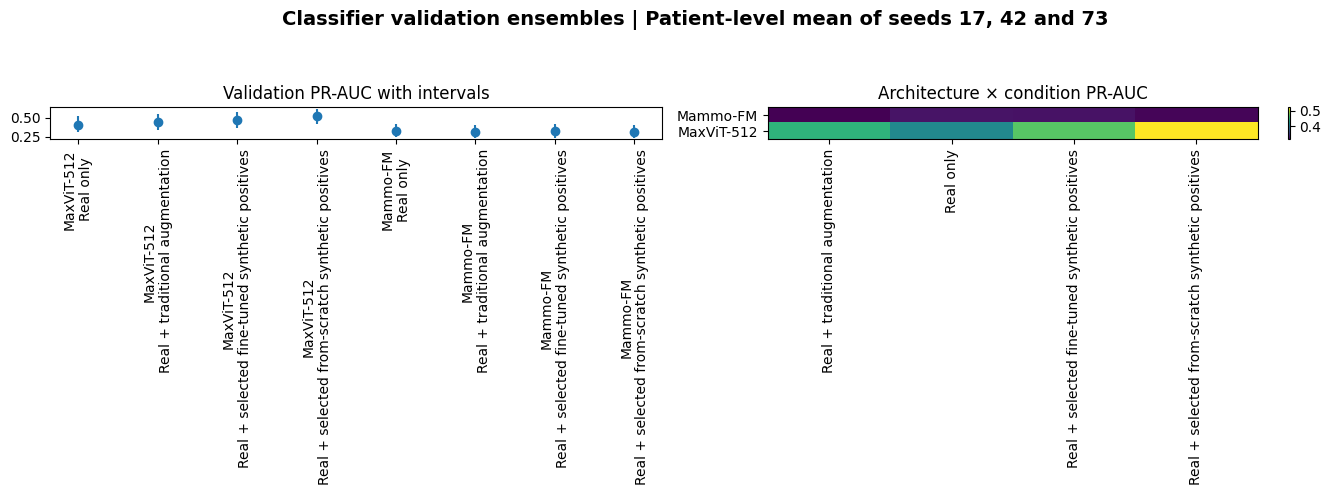

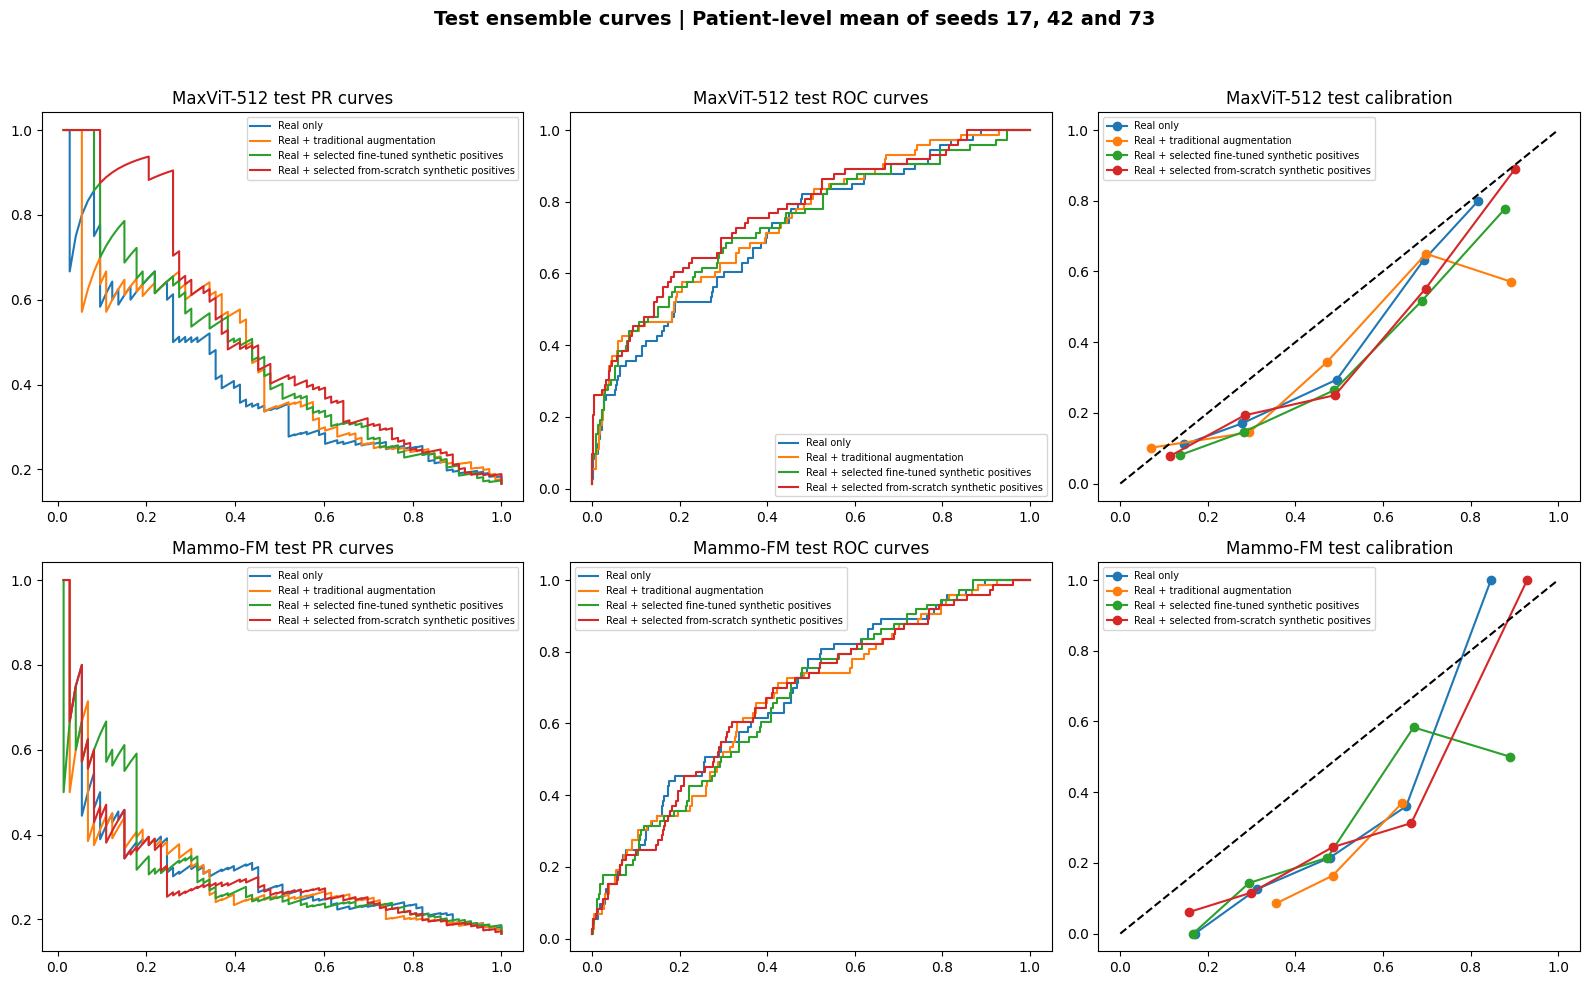

In [7]:
overview_figure = plot_ensemble_overview(test_ensembles)
curve_figure = plot_ensemble_curves(ROOT, test_ensembles, split='test')
(overview_figure, curve_figure)